# Passive Axon Cable Simulation
This notebook shows the numerical solution of the passive axon cable equation using explicit Euler, with point current injection and Dirichlet boundary conditions.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../external/")
from uNRV import Axon as NRV_axon


## 1. Passive Cable Equation

The passive cable equation:

$$
\frac{r_m}{r_a} \frac{\partial^2 V}{\partial x^2} = r_m C_m \frac{\partial V}{\partial t} + (V - E_L) - I_{inj}(x,t) r_m
$$

Where:

- $r_m = \frac{R_m}{2 \pi a}$ — specific membrane resistance $[\Omega \cdot m]$ 
- $r_a = \frac{\rho}{\pi a^2}$ — axial resistance $[\Omega /m]$  
- $c_m = 2 \pi a C_m$ — membrane capacitance $[F/m]$  

## 2. Physical Parameters
We define the axon geometry and membrane properties are derived from geometrical properties as follows:

- $r_m = \frac{R_m}{2 \pi a}$ — specific membrane resistance $[\Omega \cdot cm]$, with $R_m$ in $[\Omega \cdot cm²]$ and $a$ the axon radius in $[cm]$  
- $r_a = \frac{\rho}{\pi a^2}$ — axial resistance $[\Omega /cm]$, with $\rho$ the cytoplasmic resistivity in $[\Omega \cdot cm]$  
- $c_m = 2 \pi a C_m$ — membrane capacitance $[F/cm]$, with $C_m$ in $[F/cm²]$  
- $G_L = \frac{1}{R_m}$ — membrane leak conductance $[S/cm²]$  


In [3]:
L = 0.1                                 # axon length in cm
Nx = 201                                # number of spatial points
x = np.linspace(0, L, Nx)
dx = x[1] - x[0]

Gl = 0.001                              # conductance specifique membrane [S/cm^2]
Cm  = 10.0e-6                           # capacitance spécifique membrane [F/cm^2]
rho = 100                               # axoplasmic resistivity [ohm*cm]
a = 2.5e-4                              # axon radius [cm]
EL = -70e-3                             # resting potential [V]

Rm  = 1/Gl                              # specific membrane resistance [Ohm·cm^2]
rm = Rm / (2.0 * np.pi * a)             # ohm*cm
cm = 2.0 * np.pi * a * Cm               # F/cm
ra = rho / (np.pi * a**2)               # ohm/cm

D = 1.0 / ra / cm                      # diffusion coefficient
k = 1.0      / (rm * cm)               # membrane leak coefficient

## 3. Time Parameters
Simulation time and timestep are defined as follows.

### Stability condition for explicit Euler

Explicit Euler solver remains numerically stable if:

- $\Delta t \le \frac{\Delta x^2}{2 D}$

And:

- $\Delta t \le \frac{1}{k + 2 D / \Delta x^2}$



In [4]:
Tsim = 0.02       # simulation duration [s]

#for stability
dt_diff = (ra*cm*dx**2)/2.0
dt_leak = 2.0*rm*cm
dt  = 0.4 * min(dt_diff, dt_leak)   # security margin (0.4) 
Nt  = int(np.ceil(Tsim/dt))

## Current Injection — Equations and Unit Conversions


### Unit conversions

- **nA → $\mu\mathrm{A/cm^2}$** for a discrete segment of length $\Delta x$ and radius $a$:
$$
i_{\mathrm{surf}} \; [\mu\mathrm{A/cm}^2] 
= \frac{I_{\mathrm{inj}} \; [\mathrm{nA}]}{1000 \cdot (2 \pi a \, \Delta x)}
$$

- **$\mu\mathrm{A/cm^2} \to \mathrm{A/cm}$**:
$$
i_{\mathrm{lin}} \; [\mathrm{A/cm}]
= \left( i_{\mathrm{surf}} \; [\mu\mathrm{A/cm}^2] \times 10^{-6} \right) \cdot (2 \pi a)
$$


### 4. Discrete node injection (numerical scheme)

For a node $i_{\mathrm{inj}}$ at position $x_{i_{\mathrm{inj}}}$ and spatial step $\Delta x$:
$$
I^{\mathrm{surf}}_{i}(t) \; [\mu\mathrm{A/cm}^2] = 
\begin{cases}
\dfrac{I_{\mathrm{inj}} \; [\mathrm{nA}]}{1000 \cdot (2\pi a \, \Delta x)}, & t_{\mathrm{on}} \le t \le t_{\mathrm{off}} \ \text{and} \ i=i_{\mathrm{inj}}, \\
0, & \text{otherwise}.
\end{cases}
$$
Then convert to linear current:
$$
I^{\mathrm{lin}}_{i}(t) \; [\mathrm{A/cm}] = 
\left( I^{\mathrm{surf}}_{i}(t) \times 10^{-6} \right) \cdot (2 \pi a)
$$

---


In [5]:
# =======================
# Point current injection in nA (duration 1 ms at t=5 ms)
# =======================
I_inj_nA = 10           # in nA
I0_uA_per_cm2 = I_inj_nA * 1e-3 / (2.0 * np.pi * a * dx)
t_on  = 0.001           # 5 ms
t_start = 0.005
t_off = t_on + t_start  # duration 1 ms -> 6 ms

# injection site: central node
idx_inj = Nx // 2

def I_surf_uA_per_cm2_point(t):
    """Returns array (µA/cm^2) with a non-zero point at idx_inj."""
    if t_start <= t <= t_off:
        arr = np.zeros(Nx)
        arr[idx_inj] = I0_uA_per_cm2
        return arr
    else:
        return np.zeros(Nx)

def Ilin_from_Isurf_uA_per_cm2(Isurf_uA_per_cm2):
    """
    Converts surface current (µA/cm^2) to line current [A/cm]:
      I_lin = (Isurf [µA/cm^2] * 1e-6 A/µA) * (2*pi*a) [cm]
    """
    return (Isurf_uA_per_cm2 * 1e-6) * (2.0 * np.pi * a)

def Iinj_lin(t):
    """Linear current [A/cm] at time t (Nx-long array)."""
    return Ilin_from_Isurf_uA_per_cm2(I_surf_uA_per_cm2_point(t))


## 5. Initial Conditions and Storage

In [6]:
V = np.ones(Nx) * EL  # initial conditions [V]
V_all = np.zeros((Nt, Nx))
t_vec = np.zeros(Nt)

## Explicit Euler solver

We solve:

$$
\frac{\partial V}{\partial t} = D \frac{\partial^2 V}{\partial x^2} - k \left( V - E_L \right) + \frac{1}{c_m} I_{\mathrm{inj}}(x,t)
$$

### Spatial discretization (second-order central difference)

For interior nodes $i = 1, \dots, N_x - 2$:

$$
\frac{\partial^2 V}{\partial x^2} \approx 
\frac{V_{i+1}^n - 2 V_i^n + V_{i-1}^n}{\Delta x^2}
$$

### Time discretization (explicit Euler)

The update rule is:

$$
V_i^{n+1} = V_i^n + \Delta t \left[
D \frac{V_{i+1}^n - 2 V_i^n + V_{i-1}^n}{\Delta x^2}
- k \left( V_i^n - E_L \right)
+ \frac{1}{c_m} I_{\mathrm{inj},i}^n
\right]
$$

### 3. Boundary conditions (Dirichlet)

At each time step:

$$
V_0^{n} = E_L, \quad V_{N_x - 1}^{n} = E_L
$$

In [7]:
t = 0.0
for n in range(Nt):
    d2vdx2 = np.zeros_like(V)
    d2vdx2[1:-1] = (V[2:] - 2.0*V[1:-1] + V[:-2]) / dx**2
    dVdt = D*d2vdx2 - k*(V - EL) + Iinj_lin(t)/cm
    V = V + dt*dVdt
    V[0]  = EL
    V[-1] = EL

    V_all[n,:] = V
    t_vec[n] = t

    t += dt

## 7. Visualize Voltage with pcolormesh

Text(0.5, 1.0, 'Passive Cable')

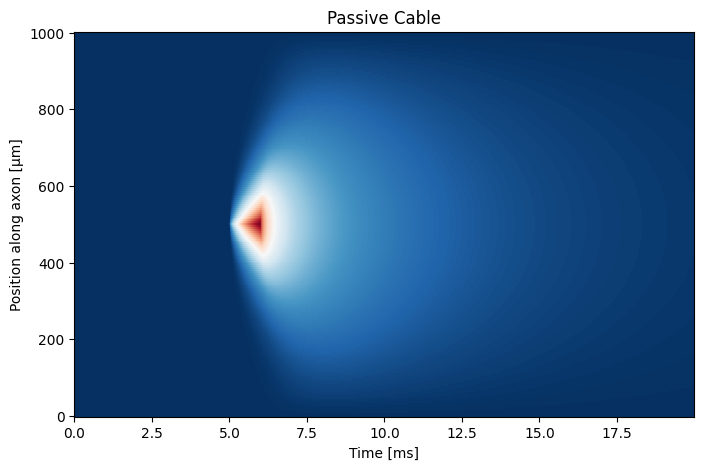

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
X, Y = np.meshgrid(t_vec*1e3, x*1e4)  # time ms, position µm
colorbar = ax.pcolormesh(X, Y, V_all.T*1e3, shading='auto', cmap='RdBu_r')
colorbar.set_label('V [mV]')
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Position along axon [µm]')
ax.set_title('Passive Cable')

## 8. Voltage at Specific Positions
We record voltage at x = 0, L/3, L/2, 2L/3, and L.

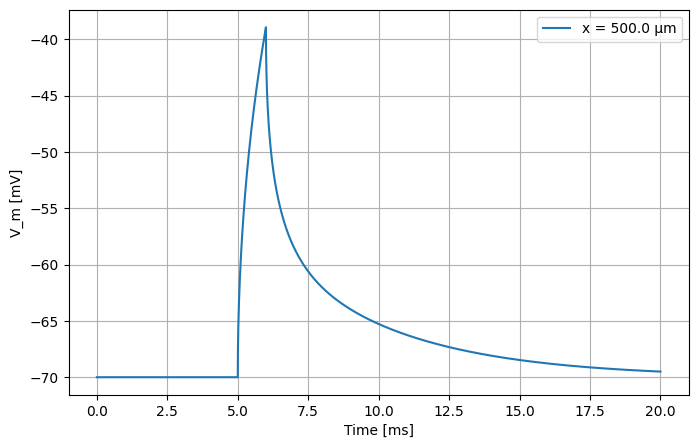

In [9]:
x_positions = [0, L/3, L/2, 2*L/3, L]
x_positions = [L/2]
indices = [np.argmin(np.abs(x - xp)) for xp in x_positions]

fig, ax_x = plt.subplots(figsize=(8,5))
for idx, xp in zip(indices, x_positions):
    ax_x.plot(t_vec*1e3, V_all[:, idx]*1e3, label=f'x = {xp*1e4:.1f} µm')
ax_x.set_xlabel('Time [ms]')
ax_x.set_ylabel('V_m [mV]')
ax_x.legend()
ax_x.grid(True)

## 9. Validation with NRV

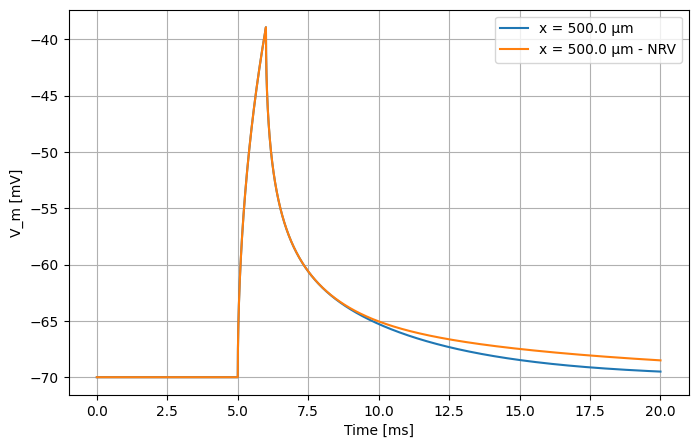

In [10]:
L_um = L*1e4    #in um
y = 0
z = 0
d = 2*a*1e4    #in um

axon = NRV_axon(
    y=y,
    z=z,
    d=d,
    L = L_um,
    Nsec = Nx,
    passif_cable = True,
    Ra = rho,
    cm = Cm*1e6,
    e_pas = EL*1e3,
    g_pas = Gl,
    dt = 0.001,
    V_init = EL*1e3
)

axon.insert_I_Clamp(0.5, t_start*1000, t_on*1000, I_inj_nA)
results_NRV = axon.simulate(t_sim=Tsim*1000)
Vm = results_NRV['V_mem']

"""
map = plt.pcolormesh(results_NRV['t'], results_NRV['x_rec'], results_NRV['V_mem'] ,shading='auto')
plt.xlabel('time (ms)')
plt.ylabel('position (µm)')
cbar = plt.colorbar(map)
cbar.set_label('membrane voltage (mV)')
plt.show()
"""

t = results_NRV['t'].ravel()          
x_rec = results_NRV['x_rec']          # positions [µm]
Vm = results_NRV['V_mem']             # shape (Nt, Nx)

L_p = x_rec[-1]
x_positions = [0, L_p/3, L_p/2, 2*L_p/3, L_p]
x_positions = [L_p/2]
indices = [np.argmin(np.abs(x_rec - xp)) for xp in x_positions]

for idx, xp in zip(indices, x_positions):
    ax_x.plot(t, Vm[idx, :], label=f"x = {xp:.1f} µm - NRV")
ax_x.legend()
fig
